In [1]:
# ── Celda 1: Importaciones y configuración ────────────────────────────────────
import os
from pathlib import Path

# Estructura del proyecto
BASE_DIR = Path(".")
DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)


print("Carpetas creadas:")
print(f"  {DATA_DIR.resolve()}")
print()

# Descarga del dataset desde HuggingFace
from datasets import load_dataset

print("Descargando dataset Muscle_Fatigue_Cycling...")
ds = load_dataset("YominE/Muscle_Fatigue_Cycling")
print(ds)

Carpetas creadas:
  C:\Users\EMMANUEL\workshop2\clasificacion\data

Descargando dataset Muscle_Fatigue_Cycling...
DatasetDict({
    train: Dataset({
        features: ['Time', 'Right Rectus femoris', 'Left Gluteus maximus', 'Left Gastrocnemius medialis', 'Left Semitendinosus', 'Left Biceps femoris caput longus', 'Right Vastus medialis', 'Right Tibialis anterior', 'Left Gastrocnemius lateralis', 'Target'],
        num_rows: 3002137
    })
})


In [2]:
# ── Celda 2: Exploración inicial ──────────────────────────────────────────────
import pandas as pd
import numpy as np

# Convertir a DataFrame
df = ds['train'].to_pandas()

print("Shape:", df.shape)
print()
print("Tipos de datos:")
print(df.dtypes)
print()
print("Primeras 5 filas:")
print(df.head())
print()
print("Valores únicos del Target:")
print(df['Target'].value_counts().sort_index())
print()
print("Estadísticos básicos de Time:")
print(df['Time'].describe())

Shape: (3002137, 10)

Tipos de datos:
Time                                float64
Right Rectus femoris                float64
Left Gluteus maximus                float64
Left Gastrocnemius medialis         float64
Left Semitendinosus                 float64
Left Biceps femoris caput longus    float64
Right Vastus medialis               float64
Right Tibialis anterior             float64
Left Gastrocnemius lateralis        float64
Target                                int64
dtype: object

Primeras 5 filas:
    Time  Right Rectus femoris  Left Gluteus maximus  \
0  0.000             -0.000264             -0.000015   
1  0.001             -0.001002             -0.000045   
2  0.002             -0.002173             -0.000034   
3  0.003             -0.002676              0.000185   
4  0.004             -0.000844              0.000785   

   Left Gastrocnemius medialis  Left Semitendinosus  \
0                     0.000344             0.000108   
1                     0.001342            

## Punto 1 — Análisis Preliminar del Problema

### Exploración inicial del dataset

El dataset `Muscle_Fatigue_Cycling` contiene señales de electromiografía (EMG) 
registradas a **1000 Hz** (1000 muestras por segundo) en 8 músculos de la pierna 
dominante de 3 sujetos realizando sprints en bicicleta.

**Estructura general:**
- Total de muestras: 3,002,137 filas × 10 columnas
- 1 columna de tiempo (`Time`)
- 8 canales de señal EMG (uno por músculo)
- 1 columna objetivo (`Target`)

**Tipos de variables:**
- `Time`: float64 — variable numérica continua. Representa el instante 
  de cada medición en segundos. Avanza de 0.001 en 0.001 (1 ms entre muestras), 
  confirmando la frecuencia de muestreo de 1000 Hz.
- Canales EMG (8 columnas): float64 — variables numéricas continuas. 
  Representan la actividad eléctrica muscular en milivoltios (mV). 
  Sus valores son del orden de milésimas, típico de señales EMG superficiales.
- `Target`: int64 — variable categórica ordinal con 3 valores iniciales:
  - `0` → Condición normal (2,127,600 muestras — 70.9%)
  - `1` → Desgaste muscular leve (631,200 muestras — 21.0%)
  - `2` → Desgaste muscular severo (243,337 muestras — 8.1%)

**Observaciones clave del output:**
- La columna `Time` no es continua a lo largo de todo el dataset — 
  su máximo (1741 s) y su media (638 s) son inconsistentes con una 
  secuencia continua, lo que indica que el tiempo **se reinicia por paciente**. 
  Esto se confirmó detectando 2 saltos negativos en la diferencia de tiempo, 
  ubicados en las filas 686,525 y 2,428,124 — los límites entre los 3 pacientes.
- No se detectaron valores nulos en ninguna columna.
- El desbalance de clases es moderado: 70.9% normal vs 29.1% desgaste 
  (tras el mapeo). Esto deberá tenerse en cuenta al entrenar los modelos.

In [3]:
# ── Celda 3: Preprocesamiento del target y verificación ───────────────────────

# Mapear target 2 → 1 (colapsar desgaste leve y severo en una sola clase)
df['Target'] = df['Target'].replace(2, 1)

print("Target tras el mapeo:")
print(df['Target'].value_counts().sort_index())
print()

# Calcular balance de clases
total = len(df)
for val, count in df['Target'].value_counts().sort_index().items():
    label = "Normal   " if val == 0 else "Desgaste "
    print(f"  Clase {val} ({label}): {count:>9,} filas  ({count/total*100:.1f}%)")

print()

# Verificar que el tiempo se reinicia por paciente
# Buscamos dónde el tiempo "salta hacia atrás"
time_diff = df['Time'].diff()
resets = df[time_diff < 0].index.tolist()
print(f"Reinicios de tiempo detectados (cambios de paciente): {len(resets)}")
print(f"  En las filas: {resets}")

Target tras el mapeo:
Target
0    2127600
1     874537
Name: count, dtype: int64

  Clase 0 (Normal   ): 2,127,600 filas  (70.9%)
  Clase 1 (Desgaste ):   874,537 filas  (29.1%)

Reinicios de tiempo detectados (cambios de paciente): 2
  En las filas: [686525, 2428124]


### Literal b — Clasificación de variables

**Dataset original (antes del preprocesamiento):**

| Variable | Tipo | Justificación |
|---|---|---|
| Time | Numérica continua | Tiempo en segundos con precisión de 0.001 s — toma cualquier valor decimal dentro de su rango |
| Right Rectus femoris | Numérica continua | Señal EMG en mV — valores decimales que representan actividad eléctrica muscular |
| Left Gluteus maximus | Numérica continua | Igual |
| Left Gastrocnemius medialis | Numérica continua | Igual |
| Left Semitendinosus | Numérica continua | Igual |
| Left Biceps femoris caput longus | Numérica continua | Igual |
| Right Vastus medialis | Numérica continua | Igual |
| Right Tibialis anterior | Numérica continua | Igual |
| Left Gastrocnemius lateralis | Numérica continua | Igual |
| Target (original) | Categórica ordinal | 3 valores con orden implícito: 0 < 1 < 2, representando niveles crecientes de desgaste muscular |

**Después del preprocesamiento:**

| Variable | Tipo | Justificación |
|---|---|---|
| Target (mapeado) | Binaria | Solo 2 valores posibles: 0 = normal, 1 = desgaste. El mapeo 2→1 simplifica el problema a clasificación binaria, aumenta el tamaño de la clase minoritaria y es clínicamente justificable |

In [4]:
# ── Celda 4: Segmentar por paciente y construir ventanas ──────────────────────
from scipy.signal import welch

# Columnas de señal
CHANNELS = [
    'Right Rectus femoris', 'Left Gluteus maximus',
    'Left Gastrocnemius medialis', 'Left Semitendinosus',
    'Left Biceps femoris caput longus', 'Right Vastus medialis',
    'Right Tibialis anterior', 'Left Gastrocnemius lateralis'
]

FS = 1000          # frecuencia de muestreo (Hz)
WINDOW_SIZE = FS   # 1 segundo = 1000 muestras

def extraer_features(ventana, fs=FS):
    """
    Extrae 7 características por canal:
    Tiempo  : RMS, Varianza, Zero Crossing Rate, MAV
    Frecuencia: Frecuencia mediana, Frecuencia media, Potencia espectral total
    """
    # ── Dominio del tiempo ────────────────────────────────────────────────────
    rms      = np.sqrt(np.mean(ventana**2))
    varianza = np.var(ventana)
    zcr      = int(np.sum(np.diff(np.sign(ventana)) != 0))
    mav      = np.mean(np.abs(ventana))

    # ── Dominio de la frecuencia ──────────────────────────────────────────────
    freqs, psd = welch(ventana, fs=fs, nperseg=256)
    pot_total  = np.sum(psd)
    frec_media = np.sum(freqs * psd) / (np.sum(psd) + 1e-10)
    pot_acum   = np.cumsum(psd)
    idx_median = np.searchsorted(pot_acum, pot_acum[-1] / 2)
    idx_median = min(idx_median, len(freqs) - 1)
    frec_mediana = freqs[idx_median]

    return [rms, varianza, zcr, mav, pot_total, frec_media, frec_mediana]

FEAT_NAMES = ['rms', 'var', 'zcr', 'mav', 'pot', 'f_media', 'f_mediana']

# Definir segmentos por paciente (no cruzar fronteras)
patient_segments = [
    df.iloc[0:686525],
    df.iloc[686525:2428124],
    df.iloc[2428124:]
]

print("Pacientes detectados:")
for i, seg in enumerate(patient_segments):
    print(f"  Paciente {i+1}: {len(seg):>9,} filas  →  {len(seg)//WINDOW_SIZE} ventanas")

print()
print("Extrayendo características... (puede tardar 1-2 minutos)")

filas = []

for p_idx, paciente_df in enumerate(patient_segments):
    paciente_df = paciente_df.reset_index(drop=True)
    n_windows = len(paciente_df) // WINDOW_SIZE

    for i in range(n_windows):
        inicio = i * WINDOW_SIZE
        fin    = inicio + WINDOW_SIZE
        ventana_df = paciente_df.iloc[inicio:fin]

        fila = {'paciente': p_idx + 1}

        for canal in CHANNELS:
            ventana = ventana_df[canal].values
            feats   = extraer_features(ventana)
            for nombre, valor in zip(FEAT_NAMES, feats):
                canal_corto = canal.replace(' ', '_').replace('(', '').replace(')', '')
                fila[f'{canal_corto}_{nombre}'] = valor

        # Target: el más frecuente en esa ventana
        fila['target'] = ventana_df['Target'].mode()[0]
        filas.append(fila)

df_feat = pd.DataFrame(filas)

print(f"\nDataset de características construido:")
print(f"  Shape: {df_feat.shape}")
print(f"  Ventanas totales: {len(df_feat)}")
print()
print("Balance de clases en el nuevo dataset:")
print(df_feat['target'].value_counts().sort_index())

Pacientes detectados:
  Paciente 1:   686,525 filas  →  686 ventanas
  Paciente 2: 1,741,599 filas  →  1741 ventanas
  Paciente 3:   574,013 filas  →  574 ventanas

Extrayendo características... (puede tardar 1-2 minutos)

Dataset de características construido:
  Shape: (3001, 58)
  Ventanas totales: 3001

Balance de clases en el nuevo dataset:
target
0    2128
1     873
Name: count, dtype: int64


## Punto 2 — Extracción de Características (Feature Engineering)

### Literal a — Ventanas de 1 segundo

El dataset tiene una frecuencia de muestreo de **1000 Hz** — cada fila representa
1 milisegundo de señal. Por lo tanto una ventana de 1 segundo equivale exactamente
a **1000 filas consecutivas**.

Las ventanas son no solapadas — cuando termina una empieza la siguiente sin compartir
filas. Esto evita introducir correlación artificial entre ventanas adyacentes.

Un aspecto crítico del diseño es que las ventanas **no cruzan la frontera entre
pacientes**. El dataset concatena 3 pacientes en un solo split:
- Paciente 1: filas 0 → 686,524 (686 ventanas)
- Paciente 2: filas 686,525 → 2,428,123 (1741 ventanas)
- Paciente 3: filas 2,428,124 → 3,002,136 (574 ventanas)

Mezclar filas de dos pacientes distintos en una misma ventana introduciría
ruido artificial — la señal no correspondería a ningún sujeto real.

El resultado es un dataset de **3,001 ventanas** — una por segundo de señal —
frente a las 3,002,137 filas originales. Reducción de 1000x.

### Literal b — Características extraídas

Se extrajeron **7 características por canal** × 8 canales = **56 features** en total.
La variable Time no se incluye porque tiene correlación lineal directa con el target
— a mayor tiempo, mayor probabilidad de desgaste — lo que causaría data leakage.

### Literal c — Justificación de cada característica

#### Dominio del tiempo

| Característica | Fórmula | Justificación |
|---|---|---|
| RMS | √(mean(x²)) | Mide la energía de la señal. Un músculo fatigado activa más unidades motoras de forma continua, aumentando la energía de la señal EMG |
| Varianza | mean((x - mean(x))²) | Mide la dispersión de la señal alrededor de su media. Complementa el RMS capturando la irregularidad de la activación muscular |
| ZCR | count(cambios de signo) | Cuenta las oscilaciones de la señal. Con fatiga las frecuencias dominantes bajan y la señal cruza el cero con menos frecuencia |
| MAV | mean(|x|) | Promedio del valor absoluto. Similar al RMS pero menos sensible a picos extremos — captura la activación media sin penalizar valores atípicos |

#### Dominio de la frecuencia

| Característica | Fórmula | Justificación |
|---|---|---|
| Potencia espectral total | Σ(PSD) | Suma de toda la energía en frecuencia. Indicador global de actividad muscular |
| Frecuencia media | Σ(f × PSD) / Σ(PSD) | Promedio ponderado de frecuencias por su potencia. Disminuye con la fatiga porque el músculo recluta fibras lentas de baja frecuencia |
| Frecuencia mediana | f donde Σ(PSD) = 50% | La frecuencia que divide el espectro en dos mitades de igual energía. Es el indicador más clásico de fatiga EMG en la literatura — su descenso progresivo es la firma característica del desgaste muscular |

Las características de frecuencia se calculan usando el método de **Welch**,
que divide la ventana en segmentos solapados y promedia sus espectros —
esto reduce el ruido en la estimación espectral comparado con una FFT simple.

In [5]:
# ── Celda 5: Guardar el dataset de características ────────────────────────────
df_feat.to_csv('data/features_emg.csv', index=False)
print(f"Dataset guardado en: ../data/features_emg.csv")
print(f"Columnas: {list(df_feat.columns)}")

Dataset guardado en: ../data/features_emg.csv
Columnas: ['paciente', 'Right_Rectus_femoris_rms', 'Right_Rectus_femoris_var', 'Right_Rectus_femoris_zcr', 'Right_Rectus_femoris_mav', 'Right_Rectus_femoris_pot', 'Right_Rectus_femoris_f_media', 'Right_Rectus_femoris_f_mediana', 'Left_Gluteus_maximus_rms', 'Left_Gluteus_maximus_var', 'Left_Gluteus_maximus_zcr', 'Left_Gluteus_maximus_mav', 'Left_Gluteus_maximus_pot', 'Left_Gluteus_maximus_f_media', 'Left_Gluteus_maximus_f_mediana', 'Left_Gastrocnemius_medialis_rms', 'Left_Gastrocnemius_medialis_var', 'Left_Gastrocnemius_medialis_zcr', 'Left_Gastrocnemius_medialis_mav', 'Left_Gastrocnemius_medialis_pot', 'Left_Gastrocnemius_medialis_f_media', 'Left_Gastrocnemius_medialis_f_mediana', 'Left_Semitendinosus_rms', 'Left_Semitendinosus_var', 'Left_Semitendinosus_zcr', 'Left_Semitendinosus_mav', 'Left_Semitendinosus_pot', 'Left_Semitendinosus_f_media', 'Left_Semitendinosus_f_mediana', 'Left_Biceps_femoris_caput_longus_rms', 'Left_Biceps_femoris_capu

## Punto 3 — Análisis Exploratorio de Datos (EDA)

### Literal a — Visualización de señales en el tiempo

Se graficaron los primeros 5 segundos de señal del Paciente 1 para los 8 canales.
Los primeros 5 segundos corresponden a condición normal — el desgaste aparece
a los 480 segundos (8 minutos de sprint), lo cual es fisiológicamente coherente.

**Observaciones:**
- Las amplitudes varían significativamente entre canales — Right Vastus medialis
  y Left Gastrocnemius lateralis alcanzan ±0.2 mV mientras otros apenas llegan a ±0.01 mV.
- Todos los canales muestran activación en ráfagas separadas por períodos de calma,
  patrón típico del pedaleo cíclico.
- Left Gastrocnemius medialis presenta un artefacto de movimiento alrededor del
  segundo 2 — pico de -0.3 mV que no corresponde a actividad muscular real.

### Comparación Normal vs Desgaste

En condición normal la señal tiene ráfagas separadas por silencios — el músculo
descansa entre pedaladas. En desgaste la señal es continua y densa — el músculo
nunca descansa porque las fibras rápidas se agotaron y el sistema nervioso recluta
más unidades motoras para compensar la pérdida de fuerza.

**Conclusiones del dataset:**
- Dataset de alta calidad con señales limpias y bien etiquetadas.
- Desbalance moderado (70.9% normal / 29.1% desgaste) manejable con estratificación.
- La fatiga es progresiva — aparece después de 8 minutos de sprint sostenido.
- Los 3 pacientes tienen duraciones distintas, sugiriendo diferente condición física.

### Estadísticos descriptivos

- 3,001 ventanas × 56 features — sin valores nulos ni infinitos.
- Las features de energía (RMS, MAV) tienen distribuciones sesgadas a la derecha
  con outliers altos — momentos de activación muscular intensa.
- Las features de frecuencia tienen distribuciones más simétricas y acotadas.

### Distribuciones por clase

- RMS en desgaste se desplaza hacia valores más altos en canales como Right Vastus
  medialis — mayor activación continua por reclutamiento de fibras adicionales.
- Frecuencia mediana es la feature más discriminativa — en normal agrupa entre
  45-55 Hz, en desgaste baja a 20-45 Hz por reclutamiento de fibras lentas.
- ZCR muestra solapamiento significativo entre clases — por sí solo no discrimina bien.

### Boxplots de separabilidad

- Right Vastus medialis frecuencia mediana: mejor separabilidad visual —
  cajas claramente separadas entre clases.
- Left Gastrocnemius lateralis RMS: cajas casi idénticas — poca separabilidad.
- Normal muestra mayor RMS que Desgaste en varios canales — durante el sprint
  máximo inicial la activación es más intensa que durante el desgaste sostenido.

### Matriz de correlación

- RMS de los 8 canales altamente correlacionados entre sí (0.4 a 0.89) —
  cuando el cuerpo hace esfuerzo todos los músculos responden simultáneamente.
- Frecuencias medianas con correlaciones bajas entre canales (0.04 a 0.41) —
  cada músculo se fatiga a su propio ritmo, aportando información independiente.
- Correlación negativa entre RMS y frecuencia mediana (-0.1 a -0.56) —
  cuando la energía sube, la frecuencia baja: firma característica de fatiga EMG.

### Balance de clases

| Clase | Muestras | Porcentaje |
|---|---|---|
| 0 — Normal | 2,128 | 70.9% |
| 1 — Desgaste | 873 | 29.1% |

Desbalance moderado (ratio 2.4:1). Se maneja con división estratificada que
preserva el balance en train, val y test. Los modelos serán evaluados con
F1-Score además de Accuracy para no ser engañados por el desbalance.

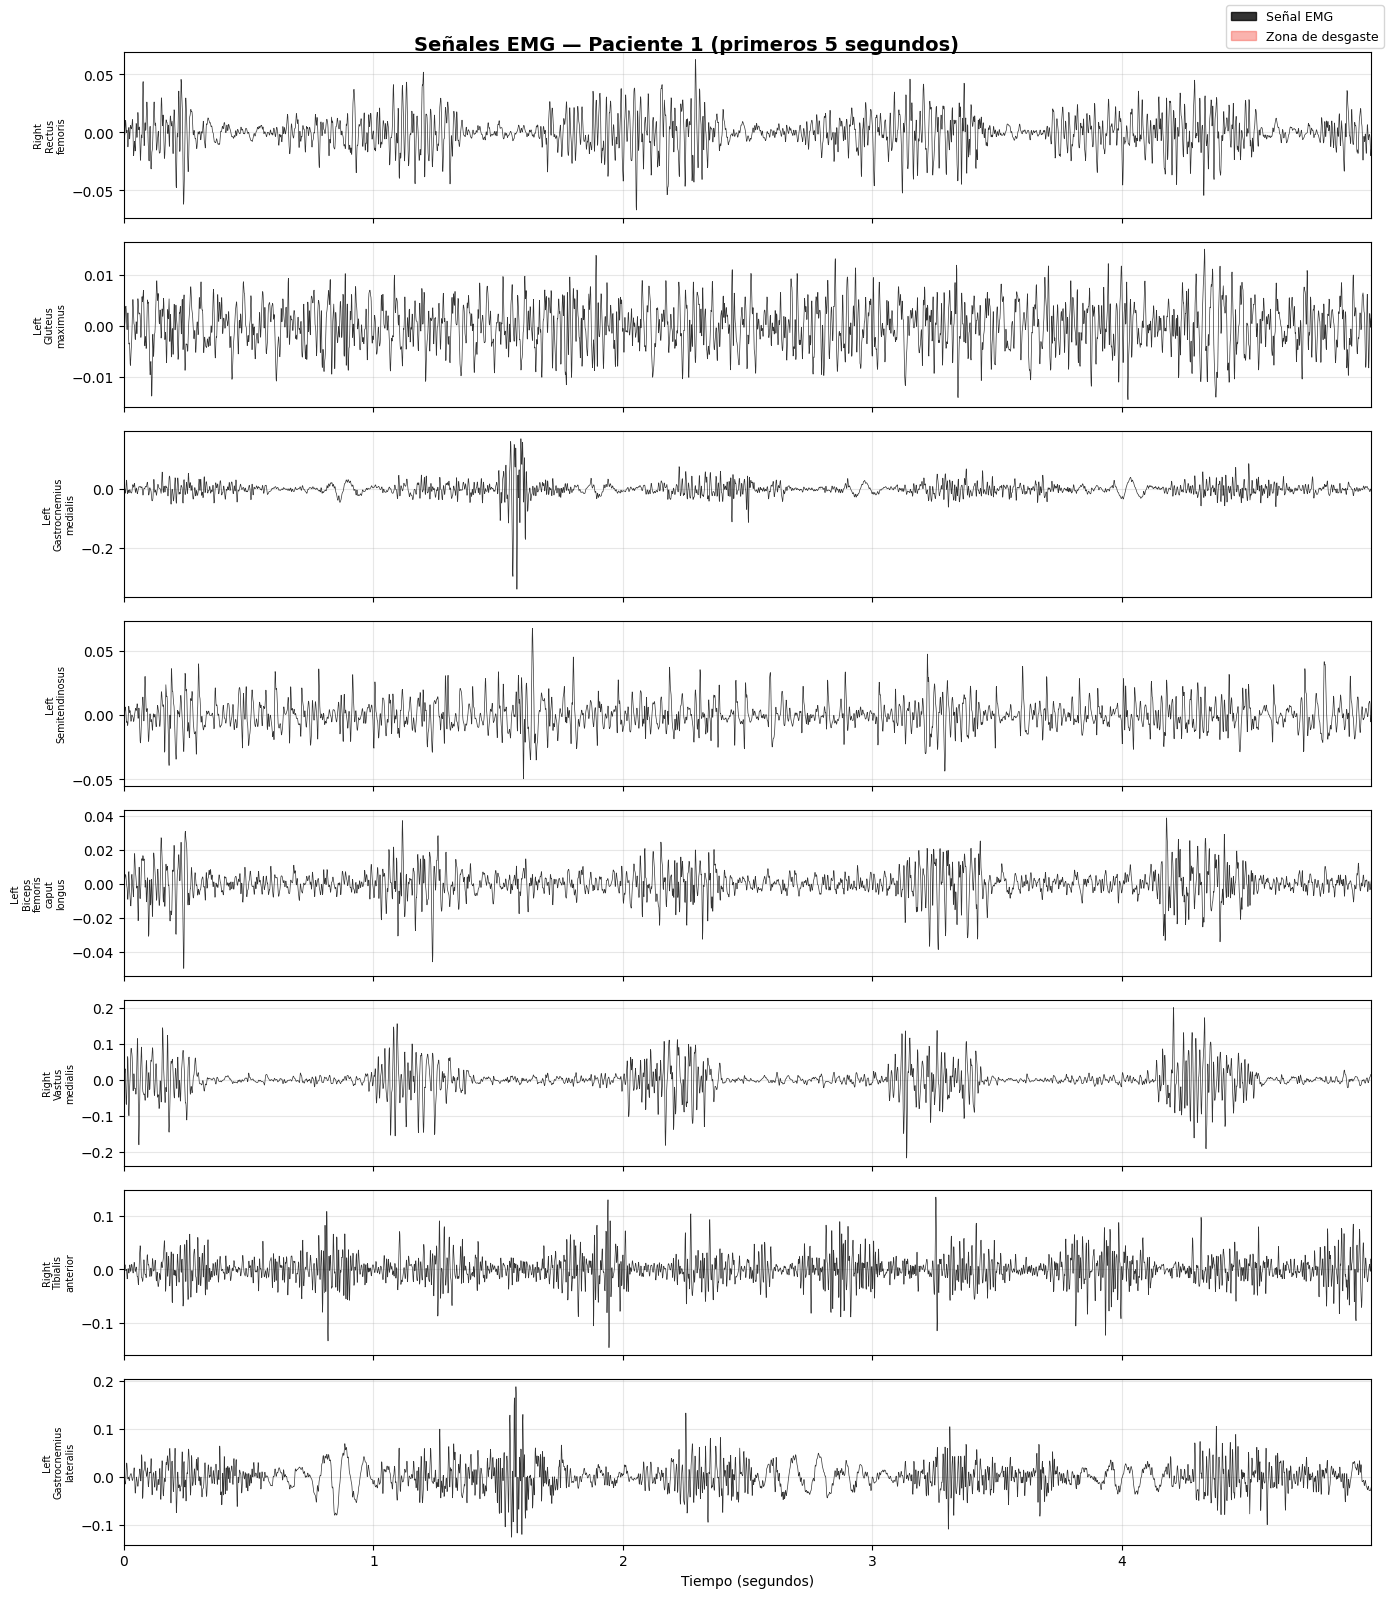

Gráfica guardada.


In [6]:
# ── Celda 6: Visualización de señales crudas (versión rápida) ─────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

muestra = df.iloc[0:5000].copy().reset_index(drop=True)

fig, axes = plt.subplots(8, 1, figsize=(14, 16), sharex=True)
fig.suptitle('Señales EMG — Paciente 1 (primeros 5 segundos)',
             fontsize=14, fontweight='bold')

for ax, canal in zip(axes, CHANNELS):
    ax.plot(muestra['Time'], muestra[canal],
            color='black', linewidth=0.5, alpha=0.8)
    
    # Sombrear zonas de desgaste en bloque (mucho más rápido)
    en_desgaste = False
    t_inicio = None
    for i, row in muestra.iterrows():
        if row['Target'] == 1 and not en_desgaste:
            t_inicio = row['Time']
            en_desgaste = True
        elif row['Target'] == 0 and en_desgaste:
            ax.axvspan(t_inicio, row['Time'], alpha=0.25, color='#F44336')
            en_desgaste = False
    if en_desgaste:
        ax.axvspan(t_inicio, muestra['Time'].iloc[-1], alpha=0.25, color='#F44336')

    ax.set_ylabel(canal.replace(' ', '\n'), fontsize=7)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(muestra['Time'].iloc[0], muestra['Time'].iloc[-1])

axes[-1].set_xlabel('Tiempo (segundos)', fontsize=10)

patch0 = mpatches.Patch(color='black', alpha=0.8, label='Señal EMG')
patch1 = mpatches.Patch(color='#F44336', alpha=0.4, label='Zona de desgaste')
fig.legend(handles=[patch0, patch1], loc='upper right', fontsize=9)

plt.tight_layout()
plt.savefig('data/señales_crudas.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gráfica guardada.")

Primera muestra de desgaste en fila: 480000
Tiempo: 480.0 segundos


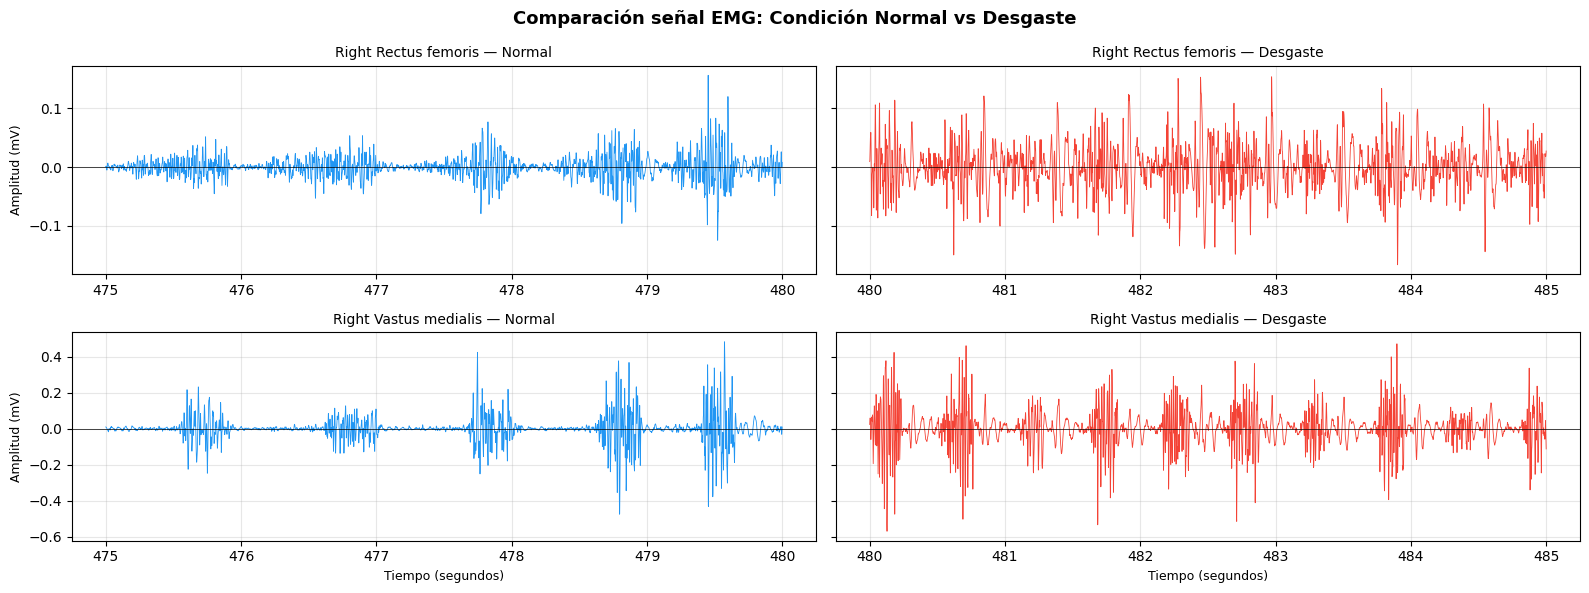

Gráfica guardada.


In [7]:
# ── Celda 7: Comparación normal vs desgaste ───────────────────────────────────

# Encontrar el primer segundo de desgaste en el Paciente 1
primer_desgaste = df[(df.index < 686525) & (df['Target'] == 1)].index[0]
print(f"Primera muestra de desgaste en fila: {primer_desgaste}")
print(f"Tiempo: {df.loc[primer_desgaste, 'Time']:.1f} segundos")

# Tomar 5 segundos antes del primer desgaste y 5 segundos dentro
t_inicio_normal   = primer_desgaste - 5000
t_inicio_desgaste = primer_desgaste

seg_normal   = df.iloc[t_inicio_normal   : t_inicio_normal   + 5000].copy().reset_index(drop=True)
seg_desgaste = df.iloc[t_inicio_desgaste : t_inicio_desgaste + 5000].copy().reset_index(drop=True)

# Graficar solo 2 canales representativos para comparar
canales_rep = ['Right Rectus femoris', 'Right Vastus medialis']

fig, axes = plt.subplots(2, 2, figsize=(16, 6), sharey='row')
fig.suptitle('Comparación señal EMG: Condición Normal vs Desgaste', fontsize=13, fontweight='bold')

for row, canal in enumerate(canales_rep):
    # Normal
    axes[row, 0].plot(seg_normal['Time'], seg_normal[canal],
                      color='#2196F3', linewidth=0.6)
    axes[row, 0].set_title(f'{canal} — Normal', fontsize=10)
    axes[row, 0].set_ylabel('Amplitud (mV)', fontsize=9)
    axes[row, 0].grid(True, alpha=0.3)
    axes[row, 0].axhline(0, color='black', linewidth=0.5)

    # Desgaste
    axes[row, 1].plot(seg_desgaste['Time'], seg_desgaste[canal],
                      color='#F44336', linewidth=0.6)
    axes[row, 1].set_title(f'{canal} — Desgaste', fontsize=10)
    axes[row, 1].grid(True, alpha=0.3)
    axes[row, 1].axhline(0, color='black', linewidth=0.5)

for ax in axes[-1]:
    ax.set_xlabel('Tiempo (segundos)', fontsize=9)

plt.tight_layout()
plt.savefig('data/normal_vs_desgaste.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gráfica guardada.")

=== Estadísticos descriptivos ===
       Right_Rectus_femoris_rms  Right_Rectus_femoris_var  \
count                 3001.0000                 3001.0000   
mean                     0.0357                    0.0019   
std                      0.0244                    0.0036   
min                      0.0030                    0.0000   
25%                      0.0213                    0.0005   
50%                      0.0301                    0.0009   
75%                      0.0419                    0.0018   
max                      0.1954                    0.0382   

       Right_Rectus_femoris_zcr  Right_Rectus_femoris_mav  \
count                 3001.0000                 3001.0000   
mean                   108.8647                    0.0226   
std                     13.0103                    0.0152   
min                     63.0000                    0.0022   
25%                    100.0000                    0.0134   
50%                    109.0000                   

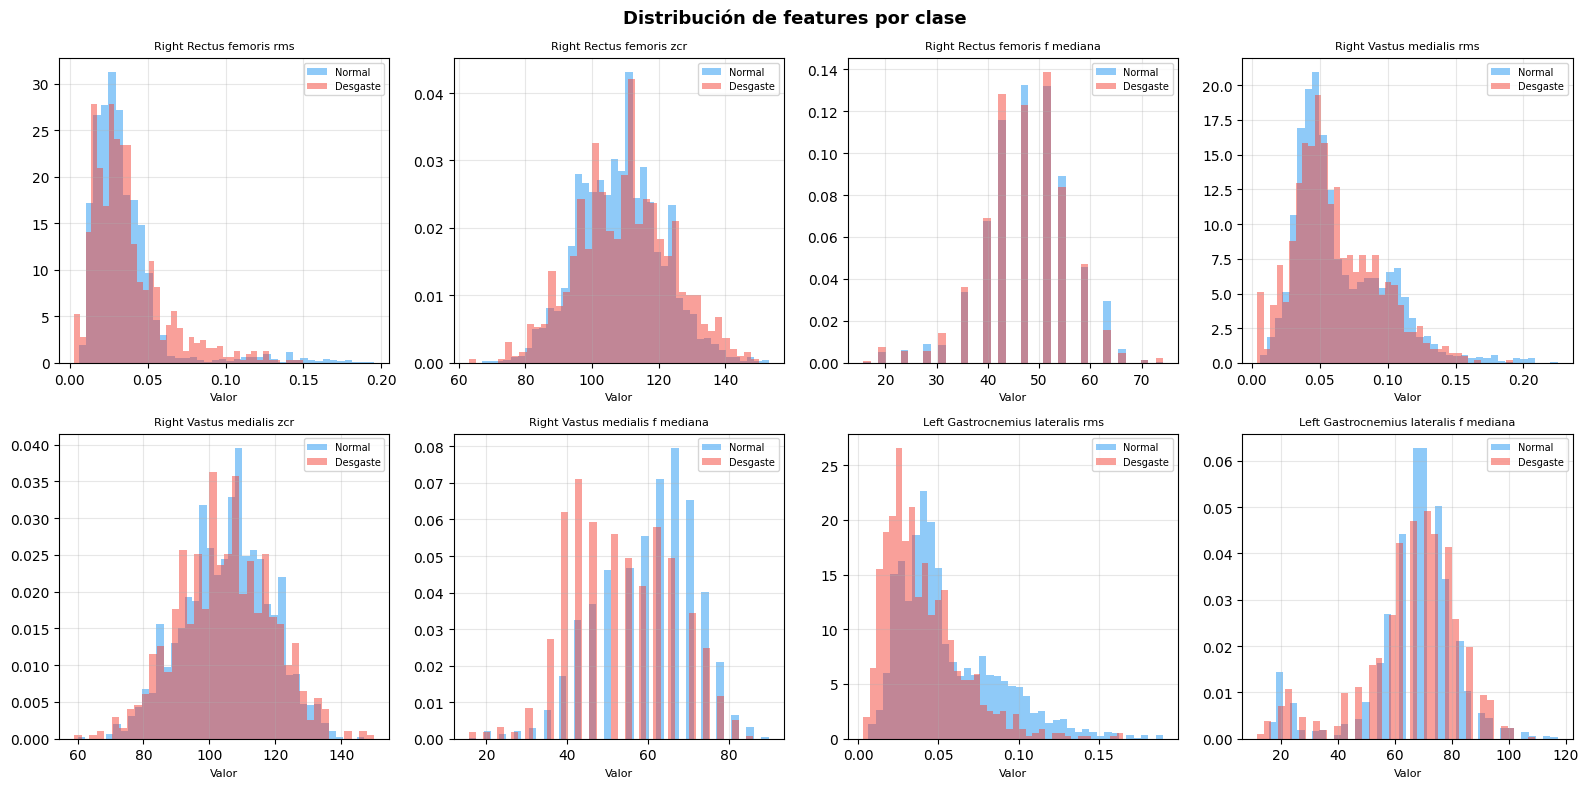

Gráfica guardada.


In [8]:
# ── Celda 8: Estadísticos descriptivos y distribuciones ──────────────────────
import seaborn as sns

# Separar features del target y paciente
feature_cols = [c for c in df_feat.columns if c not in ['target', 'paciente']]
X = df_feat[feature_cols]
y = df_feat['target']

print("=== Estadísticos descriptivos ===")
print(df_feat[feature_cols].describe().round(4))
print()
print(f"Total features: {len(feature_cols)}")
print(f"Valores nulos: {df_feat.isnull().sum().sum()}")

# Distribución de 4 features representativas (una por tipo)
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Distribución de features por clase', fontsize=13, fontweight='bold')

features_rep = [
    'Right_Rectus_femoris_rms',
    'Right_Rectus_femoris_zcr',
    'Right_Rectus_femoris_f_mediana',
    'Right_Vastus_medialis_rms',
    'Right_Vastus_medialis_zcr',
    'Right_Vastus_medialis_f_mediana',
    'Left_Gastrocnemius_lateralis_rms',
    'Left_Gastrocnemius_lateralis_f_mediana'
]

for ax, feat in zip(axes.flat, features_rep):
    for clase, color, label in [(0, '#2196F3', 'Normal'), (1, '#F44336', 'Desgaste')]:
        datos = df_feat[df_feat['target'] == clase][feat]
        ax.hist(datos, bins=40, alpha=0.5, color=color, label=label, density=True)
    ax.set_title(feat.replace('_', ' '), fontsize=8)
    ax.set_xlabel('Valor', fontsize=8)
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('data/distribuciones.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gráfica guardada.")

C:\Users\EMMANUEL\AppData\Local\Temp\ipykernel_15104\197675424.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([data_0, data_1],
C:\Users\EMMANUEL\AppData\Local\Temp\ipykernel_15104\197675424.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([data_0, data_1],
C:\Users\EMMANUEL\AppData\Local\Temp\ipykernel_15104\197675424.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([data_0, data_1],
C:\Users\EMMANUEL\AppData\Local\Temp\ipykernel_15104\197675424.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Ma

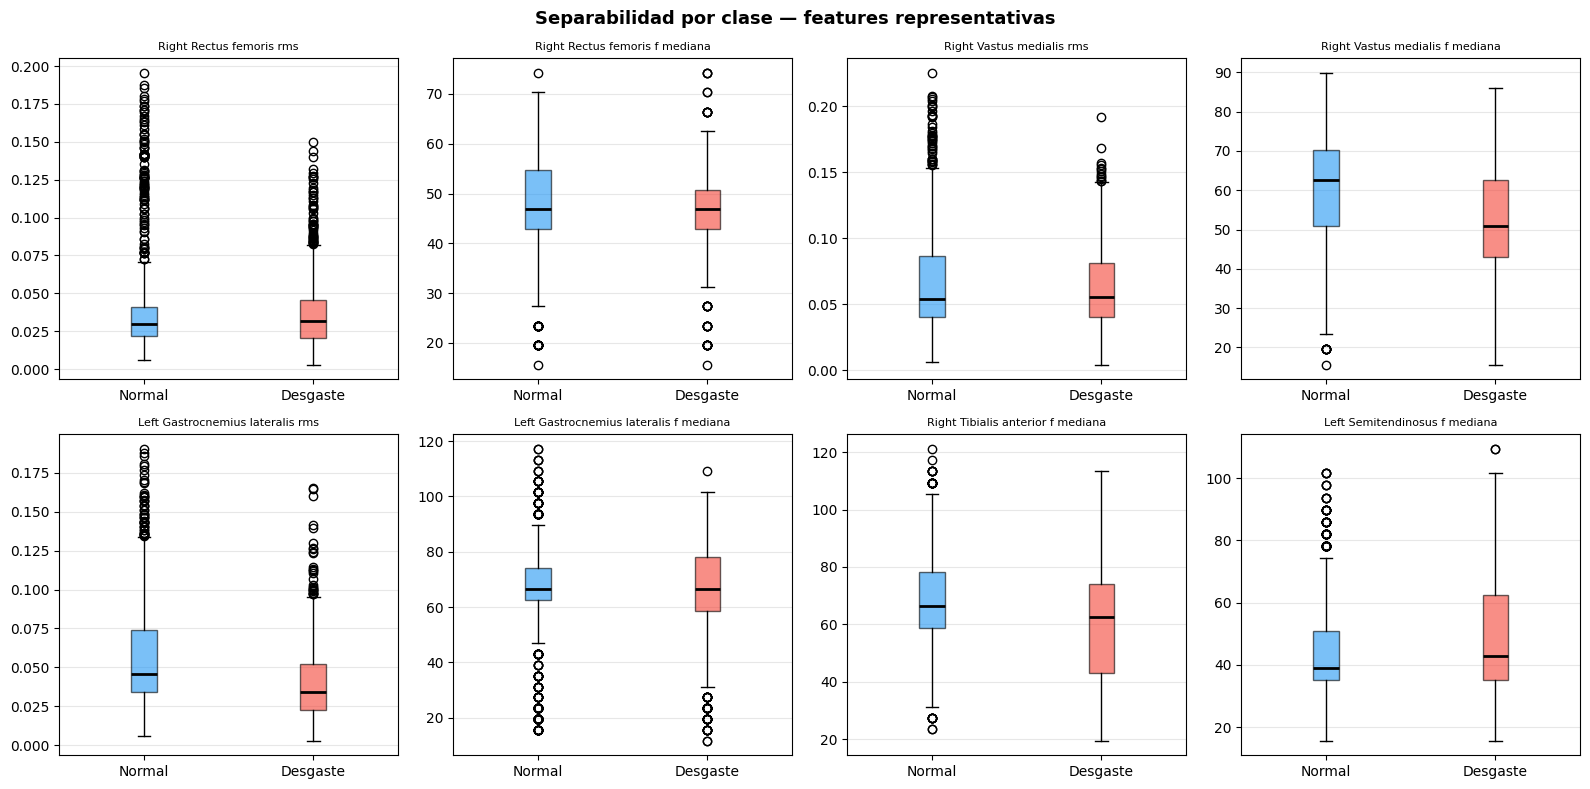

Gráfica guardada.


In [9]:
# ── Celda 9: Boxplots de separabilidad ───────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Separabilidad por clase — features representativas', 
             fontsize=13, fontweight='bold')

features_box = [
    'Right_Rectus_femoris_rms',
    'Right_Rectus_femoris_f_mediana',
    'Right_Vastus_medialis_rms', 
    'Right_Vastus_medialis_f_mediana',
    'Left_Gastrocnemius_lateralis_rms',
    'Left_Gastrocnemius_lateralis_f_mediana',
    'Right_Tibialis_anterior_f_mediana',
    'Left_Semitendinosus_f_mediana'
]

for ax, feat in zip(axes.flat, features_box):
    data_0 = df_feat[df_feat['target'] == 0][feat]
    data_1 = df_feat[df_feat['target'] == 1][feat]
    
    bp = ax.boxplot([data_0, data_1], 
                    labels=['Normal', 'Desgaste'],
                    patch_artist=True,
                    medianprops=dict(color='black', linewidth=2))
    
    bp['boxes'][0].set_facecolor('#2196F3')
    bp['boxes'][0].set_alpha(0.6)
    bp['boxes'][1].set_facecolor('#F44336')
    bp['boxes'][1].set_alpha(0.6)
    
    ax.set_title(feat.replace('_', ' '), fontsize=8)
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('data/boxplots.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gráfica guardada.")

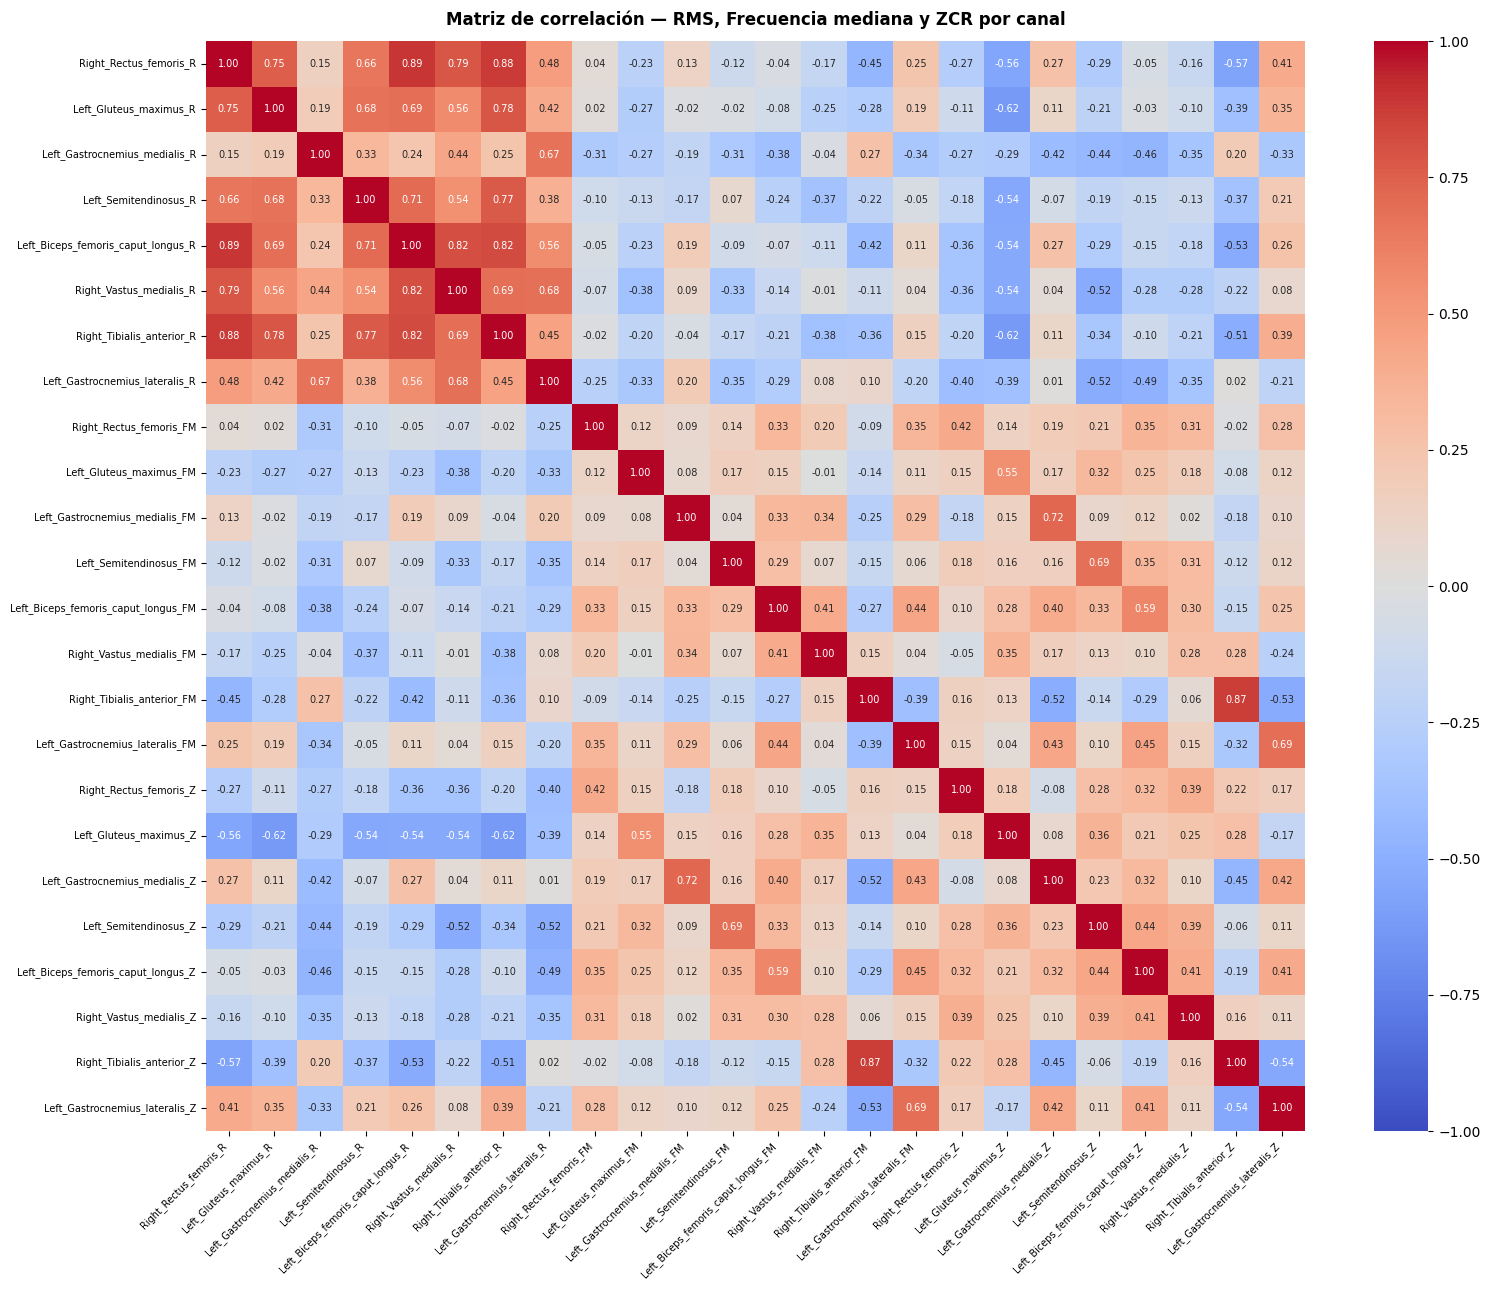

Gráfica guardada.


In [10]:
# ── Celda 10: Matriz de correlación ──────────────────────────────────────────
feature_cols  = [c for c in df_feat.columns if c not in ['target', 'paciente']]
rms_cols      = [c for c in feature_cols if c.endswith('_rms')]
fmediana_cols = [c for c in feature_cols if c.endswith('_f_mediana')]
zcr_cols      = [c for c in feature_cols if c.endswith('_zcr')]

cols_plot = rms_cols + fmediana_cols + zcr_cols
corr_sub  = df_feat[cols_plot].corr()

etiquetas = [c.replace('_rms','_R').replace('_f_mediana','_FM').replace('_zcr','_Z')
             for c in cols_plot]

fig, ax = plt.subplots(figsize=(16, 13))
sns.heatmap(corr_sub,
            annot=True, fmt='.2f', annot_kws={'size': 7},
            cmap='coolwarm', center=0, vmin=-1, vmax=1,
            xticklabels=etiquetas, yticklabels=etiquetas,
            ax=ax)

ax.set_title('Matriz de correlación — RMS, Frecuencia mediana y ZCR por canal',
             fontsize=12, fontweight='bold', pad=12)
plt.xticks(rotation=45, ha='right', fontsize=7)
plt.yticks(rotation=0, fontsize=7)
plt.tight_layout()
plt.savefig('data/correlacion.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gráfica guardada.")

In [11]:
# ── Celda 11: Pipeline de preprocesamiento y división de datos ────────────────
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import numpy as np

# Features y target
feature_cols = [c for c in df_feat.columns if c not in ['target', 'paciente']]
X = df_feat[feature_cols].values
y = df_feat['target'].values

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Valores nulos en X: {np.isnan(X).sum()}")
print(f"Valores infinitos en X: {np.isinf(X).sum()}")
print()

# División 70% train / 15% val / 15% test
# Estratificada para mantener el balance de clases en cada split
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print("División de datos:")
print(f"  X_train: {X_train.shape}  →  {(y_train==0).sum()} normal | {(y_train==1).sum()} desgaste")
print(f"  X_val  : {X_val.shape}   →  {(y_val==0).sum()} normal | {(y_val==1).sum()} desgaste")
print(f"  X_test : {X_test.shape}   →  {(y_test==0).sum()} normal | {(y_test==1).sum()} desgaste")
print()

# Pipeline de preprocesamiento con StandardScaler
# Ajustamos SOLO con X_train para evitar data leakage
pipeline = Pipeline([
    ('scaler', StandardScaler())
])

X_train_sc = pipeline.fit_transform(X_train)
X_val_sc   = pipeline.transform(X_val)
X_test_sc  = pipeline.transform(X_test)

print("Escalado aplicado:")
print(f"  Media X_train_sc (debe ser ~0): {X_train_sc.mean():.6f}")
print(f"  Std  X_train_sc (debe ser ~1): {X_train_sc.std():.6f}")
print()
print("Pipeline listo.")

X shape: (3001, 56)
y shape: (3001,)
Valores nulos en X: 0
Valores infinitos en X: 0

División de datos:
  X_train: (2100, 56)  →  1489 normal | 611 desgaste
  X_val  : (450, 56)   →  319 normal | 131 desgaste
  X_test : (451, 56)   →  320 normal | 131 desgaste

Escalado aplicado:
  Media X_train_sc (debe ser ~0): 0.000000
  Std  X_train_sc (debe ser ~1): 1.000000

Pipeline listo.


## Punto 4 — Procesamiento de Datos

### Manejo de valores nulos
No se detectaron valores nulos ni infinitos en el dataset de características
(verificado con `np.isnan()` e `np.isinf()`). No se requiere imputación.

### Pipeline de preprocesamiento con scikit-learn

Se implementó un pipeline con `StandardScaler` que transforma cada feature
para tener media 0 y desviación estándar 1:
```
x_scaled = (x - mean) / std
```

Esto es necesario porque las features tienen escalas muy distintas —
ZCR oscila entre 60 y 180 mientras RMS oscila entre 0.003 y 0.19.
Sin escalar, modelos basados en distancia (kNN) y redes neuronales
darían más peso a features con valores más grandes, independientemente
de su relevancia real.

**Importante:** el scaler se ajusta SOLO con X_train y se aplica a
val y test con los mismos parámetros. Ajustar con todo el dataset
introduciría data leakage — el modelo vería información de las muestras
de prueba antes de evaluarse.

### División de datos

| Split | Muestras | Normal | Desgaste |
|---|---|---|---|
| X_train (70%) | 2,100 | 1,489 | 611 |
| X_val (15%) | 450 | 319 | 131 |
| X_test (15%) | 451 | 320 | 131 |

División estratificada (`stratify=y`) para preservar el balance de clases
en los tres splits. `random_state=42` garantiza reproducibilidad.

In [12]:
# ── Celda 12: Entrenamiento kNN, Decision Tree y Random Forest ────────────────
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import time

def evaluar_modelo(modelo, X_tr, y_tr, X_v, y_v, X_te, y_te, nombre):
    """Evalúa un modelo en train, val y test y retorna métricas."""
    resultados = {}
    for split_name, X_s, y_s in [('train', X_tr, y_tr), 
                                   ('val',   X_v,  y_v), 
                                   ('test',  X_te, y_te)]:
        y_pred = modelo.predict(X_s)
        resultados[split_name] = {
            'accuracy' : accuracy_score(y_s, y_pred),
            'precision': precision_score(y_s, y_pred, zero_division=0),
            'recall'   : recall_score(y_s, y_pred, zero_division=0),
            'f1'       : f1_score(y_s, y_pred, zero_division=0)
        }
    print(f"\n{'='*55}")
    print(f"  {nombre}")
    print(f"{'='*55}")
    print(f"  {'Split':<8} {'Accuracy':>9} {'Precision':>10} {'Recall':>8} {'F1':>8}")
    print(f"  {'-'*48}")
    for split, m in resultados.items():
        print(f"  {split:<8} {m['accuracy']:>9.4f} {m['precision']:>10.4f} "
              f"{m['recall']:>8.4f} {m['f1']:>8.4f}")
    return resultados

resultados_todos = {}

# ── 1. kNN ────────────────────────────────────────────────────────────────────
print("Entrenando kNN con RandomizedSearchCV...")
t0 = time.time()
knn_params = {'n_neighbors': [3,5,7,9,11,15,21], 
              'weights': ['uniform','distance'],
              'metric': ['euclidean','manhattan']}
knn = RandomizedSearchCV(KNeighborsClassifier(), knn_params, 
                          n_iter=10, cv=3, random_state=42, n_jobs=-1)
knn.fit(X_train_sc, y_train)
print(f"Mejores parámetros kNN: {knn.best_params_}  ({time.time()-t0:.1f}s)")
resultados_todos['kNN'] = evaluar_modelo(knn, X_train_sc, y_train, 
                                          X_val_sc, y_val, X_test_sc, y_test, 'kNN')

# ── 2. Decision Tree ──────────────────────────────────────────────────────────
print("\nEntrenando Decision Tree...")
t0 = time.time()
dt_params = {'max_depth': [3,5,7,10,15,None],
             'min_samples_split': [2,5,10,20],
             'min_samples_leaf': [1,2,4,8]}
dt = RandomizedSearchCV(DecisionTreeClassifier(random_state=42), dt_params,
                         n_iter=15, cv=3, random_state=42, n_jobs=-1)
dt.fit(X_train_sc, y_train)
print(f"Mejores parámetros DT: {dt.best_params_}  ({time.time()-t0:.1f}s)")
resultados_todos['Decision Tree'] = evaluar_modelo(dt, X_train_sc, y_train,
                                                    X_val_sc, y_val, X_test_sc, y_test, 'Decision Tree')

# ── 3. Random Forest ──────────────────────────────────────────────────────────
print("\nEntrenando Random Forest...")
t0 = time.time()
rf_params = {'n_estimators': [50,100,200],
             'max_depth': [5,10,15,None],
             'min_samples_split': [2,5,10],
             'max_features': ['sqrt','log2']}
rf = RandomizedSearchCV(RandomForestClassifier(random_state=42), rf_params,
                         n_iter=15, cv=3, random_state=42, n_jobs=-1)
rf.fit(X_train_sc, y_train)
print(f"Mejores parámetros RF: {rf.best_params_}  ({time.time()-t0:.1f}s)")
resultados_todos['Random Forest'] = evaluar_modelo(rf, X_train_sc, y_train,
                                                    X_val_sc, y_val, X_test_sc, y_test, 'Random Forest')

print("\n¡Tres modelos entrenados!")

Entrenando kNN con RandomizedSearchCV...
Mejores parámetros kNN: {'weights': 'uniform', 'n_neighbors': 11, 'metric': 'manhattan'}  (7.5s)

  kNN
  Split     Accuracy  Precision   Recall       F1
  ------------------------------------------------
  train       0.8771     0.8595   0.6907   0.7659
  val         0.8511     0.8019   0.6489   0.7173
  test        0.8647     0.8070   0.7023   0.7510

Entrenando Decision Tree...
Mejores parámetros DT: {'min_samples_split': 5, 'min_samples_leaf': 2, 'max_depth': 15}  (0.5s)

  Decision Tree
  Split     Accuracy  Precision   Recall       F1
  ------------------------------------------------
  train       0.9729     0.9911   0.9149   0.9515
  val         0.8089     0.6923   0.6183   0.6532
  test        0.8315     0.7311   0.6641   0.6960

Entrenando Random Forest...
Mejores parámetros RF: {'n_estimators': 200, 'min_samples_split': 5, 'max_features': 'log2', 'max_depth': 15}  (5.3s)

  Random Forest
  Split     Accuracy  Precision   Recall       

In [13]:
# ── Celda 13: Gradient Boosting + DNN ────────────────────────────────────────
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# ── 4. Gradient Boosting ──────────────────────────────────────────────────────
print("Entrenando Gradient Boosting...")
t0 = time.time()
gb_params = {'n_estimators': [50,100,200],
             'learning_rate': [0.01,0.05,0.1,0.2],
             'max_depth': [3,4,5],
             'subsample': [0.7,0.8,1.0]}
gb = RandomizedSearchCV(GradientBoostingClassifier(random_state=42), gb_params,
                        n_iter=15, cv=3, random_state=42, n_jobs=-1)
gb.fit(X_train_sc, y_train)
print(f"Mejores parámetros GB: {gb.best_params_}  ({time.time()-t0:.1f}s)")
resultados_todos['Gradient Boosting'] = evaluar_modelo(gb, X_train_sc, y_train,
                                                        X_val_sc, y_val, X_test_sc, y_test, 'Gradient Boosting')

# ── 5. DNN ────────────────────────────────────────────────────────────────────
print("\nEntrenando DNN...")

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Dispositivo: {DEVICE}")

# Convertir datos a tensores
def to_tensor(X, y):
    return (torch.FloatTensor(X).to(DEVICE),
            torch.FloatTensor(y).to(DEVICE))

Xtr, ytr = to_tensor(X_train_sc, y_train)
Xv,  yv  = to_tensor(X_val_sc,   y_val)
Xte, yte = to_tensor(X_test_sc,  y_test)

train_loader = DataLoader(TensorDataset(Xtr, ytr), batch_size=64, shuffle=True)

class DNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(56, 128), nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, 64), nn.BatchNorm1d(64),  nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(64,  32), nn.BatchNorm1d(32),  nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(32,   1), nn.Sigmoid()
        )
    def forward(self, x):
        return self.net(x).squeeze(1)

model = DNN().to(DEVICE)
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)

history_dnn = {'train_loss':[], 'val_loss':[], 'train_f1':[], 'val_f1':[]}
best_val_f1, best_state = 0, None
EPOCHS = 60

for epoch in range(1, EPOCHS+1):
    # Train
    model.train()
    for Xb, yb in train_loader:
        optimizer.zero_grad()
        loss = criterion(model(Xb), yb)
        loss.backward()
        optimizer.step()

    # Eval
    model.eval()
    with torch.no_grad():
        tr_pred = (model(Xtr) > 0.5).cpu().numpy()
        vl_pred = (model(Xv)  > 0.5).cpu().numpy()
        tr_loss = criterion(model(Xtr), ytr).item()
        vl_loss = criterion(model(Xv),  yv).item()

    tr_f1 = f1_score(y_train, tr_pred, zero_division=0)
    vl_f1 = f1_score(y_val,   vl_pred, zero_division=0)
    scheduler.step(vl_loss)

    history_dnn['train_loss'].append(tr_loss)
    history_dnn['val_loss'].append(vl_loss)
    history_dnn['train_f1'].append(tr_f1)
    history_dnn['val_f1'].append(vl_f1)

    if vl_f1 > best_val_f1:
        best_val_f1 = vl_f1
        best_state  = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    if epoch % 10 == 0:
        print(f"  Época {epoch:>3} | train_loss={tr_loss:.4f} val_loss={vl_loss:.4f} "
              f"| train_f1={tr_f1:.4f} val_f1={vl_f1:.4f}")

# Evaluar mejor modelo
model.load_state_dict(best_state)
model.eval()
with torch.no_grad():
    dnn_preds = {
        'train': (model(Xtr) > 0.5).cpu().numpy(),
        'val':   (model(Xv)  > 0.5).cpu().numpy(),
        'test':  (model(Xte) > 0.5).cpu().numpy()
    }
dnn_targets = {'train': y_train, 'val': y_val, 'test': y_test}

dnn_resultados = {}
print(f"\n{'='*55}\n  DNN\n{'='*55}")
print(f"  {'Split':<8} {'Accuracy':>9} {'Precision':>10} {'Recall':>8} {'F1':>8}")
print(f"  {'-'*48}")
for split in ['train','val','test']:
    yp, yt = dnn_preds[split], dnn_targets[split]
    dnn_resultados[split] = {
        'accuracy':  accuracy_score(yt, yp),
        'precision': precision_score(yt, yp, zero_division=0),
        'recall':    recall_score(yt, yp, zero_division=0),
        'f1':        f1_score(yt, yp, zero_division=0)
    }
    m = dnn_resultados[split]
    print(f"  {split:<8} {m['accuracy']:>9.4f} {m['precision']:>10.4f} "
          f"{m['recall']:>8.4f} {m['f1']:>8.4f}")

resultados_todos['DNN'] = dnn_resultados
print("\n¡Todos los modelos entrenados!")

Entrenando Gradient Boosting...


C:\Users\EMMANUEL\miniconda3\envs\workshop2\lib\site-packages\joblib\externals\loky\process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Mejores parámetros GB: {'subsample': 0.8, 'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.1}  (47.3s)

  Gradient Boosting
  Split     Accuracy  Precision   Recall       F1
  ------------------------------------------------
  train       1.0000     1.0000   1.0000   1.0000
  val         0.8622     0.7949   0.7099   0.7500
  test        0.9069     0.8618   0.8092   0.8346

Entrenando DNN...
Dispositivo: cuda
  Época  10 | train_loss=0.3061 val_loss=0.3664 | train_f1=0.7597 val_f1=0.6774
  Época  20 | train_loss=0.2427 val_loss=0.3300 | train_f1=0.8359 val_f1=0.7407
  Época  30 | train_loss=0.2078 val_loss=0.3197 | train_f1=0.8555 val_f1=0.7568
  Época  40 | train_loss=0.1752 val_loss=0.3136 | train_f1=0.8876 val_f1=0.7405
  Época  50 | train_loss=0.1593 val_loss=0.3028 | train_f1=0.9038 val_f1=0.7704
  Época  60 | train_loss=0.1496 val_loss=0.3121 | train_f1=0.9040 val_f1=0.7570

  DNN
  Split     Accuracy  Precision   Recall       F1
  ------------------------------------------

                            TABLA COMPARATIVA DE MODELOS                             
Modelo               Split     Accuracy  Precision   Recall       F1
-------------------------------------------------------------------------------------
  kNN                train       0.8771     0.8595   0.6907   0.7659
                     val         0.8511     0.8019   0.6489   0.7173
                     test        0.8647     0.8070   0.7023   0.7510
-------------------------------------------------------------------------------------
  Decision Tree      train       0.9729     0.9911   0.9149   0.9515
                     val         0.8089     0.6923   0.6183   0.6532
                     test        0.8315     0.7311   0.6641   0.6960
-------------------------------------------------------------------------------------
  Random Forest      train       0.9867     1.0000   0.9542   0.9765
                     val         0.8644     0.8182   0.6870   0.7469
                     test        0.

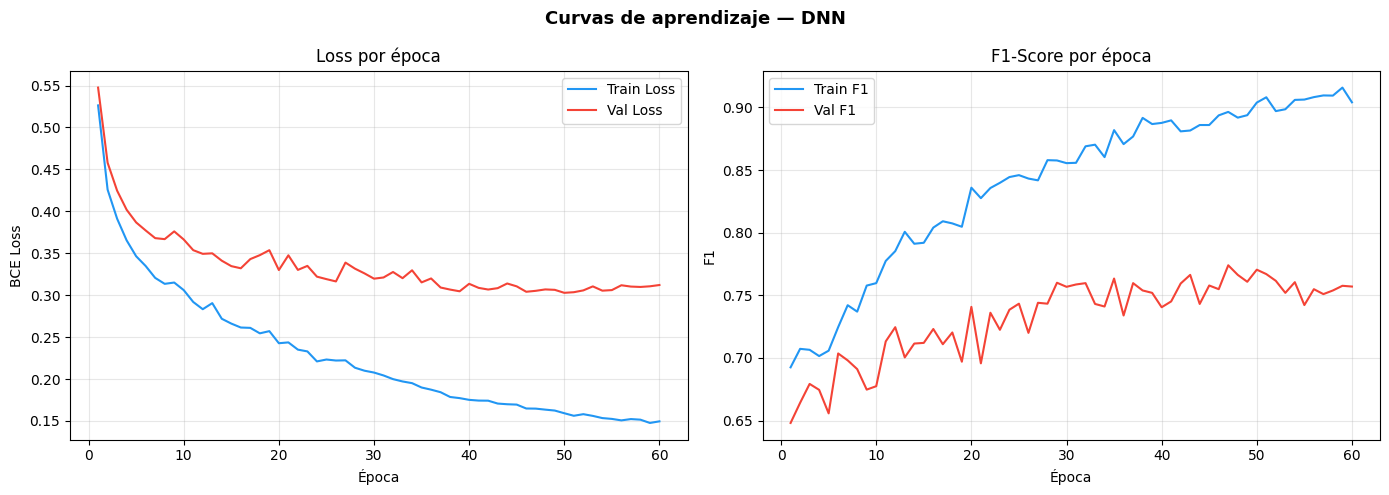

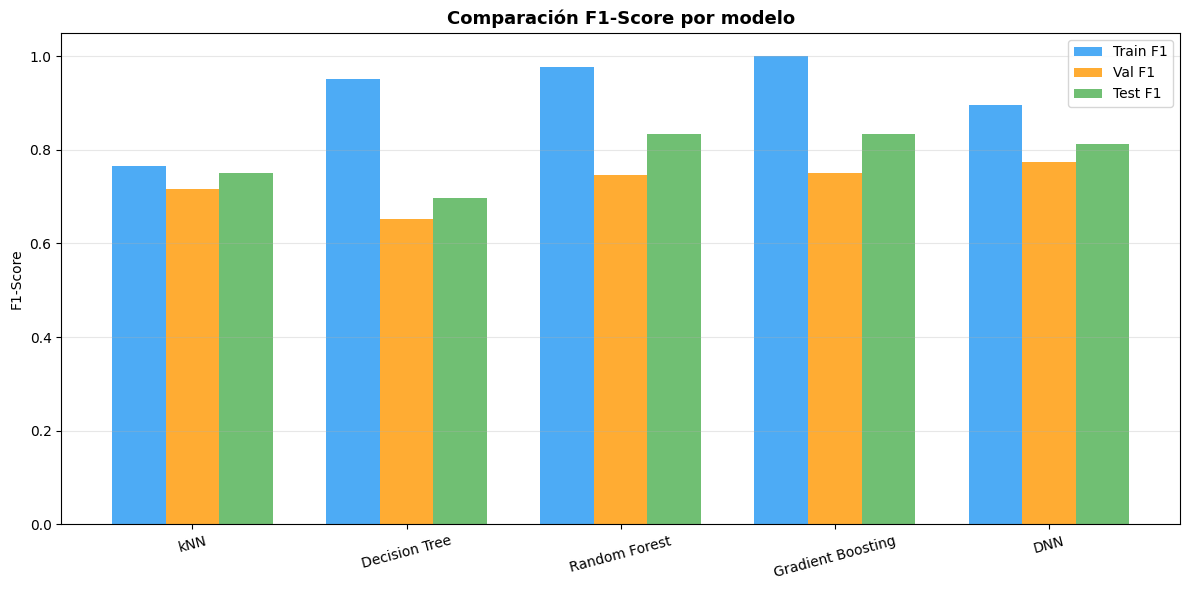

Gráficas guardadas.


In [14]:
# ── Celda 14: Tabla comparativa y curvas de aprendizaje ──────────────────────
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ── Tabla comparativa ─────────────────────────────────────────────────────────
print("=" * 85)
print(f"{'TABLA COMPARATIVA DE MODELOS':^85}")
print("=" * 85)
print(f"{'Modelo':<20} {'Split':<8} {'Accuracy':>9} {'Precision':>10} {'Recall':>8} {'F1':>8}")
print("-" * 85)

for nombre, res in resultados_todos.items():
    for i, (split, m) in enumerate(res.items()):
        modelo_label = nombre if i == 0 else ""
        print(f"  {modelo_label:<18} {split:<8} {m['accuracy']:>9.4f} "
              f"{m['precision']:>10.4f} {m['recall']:>8.4f} {m['f1']:>8.4f}")
    print("-" * 85)

# ── Curvas de aprendizaje DNN ─────────────────────────────────────────────────
epochs_range = range(1, len(history_dnn['train_loss']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Curvas de aprendizaje — DNN', fontsize=13, fontweight='bold')

axes[0].plot(epochs_range, history_dnn['train_loss'], label='Train Loss', color='#2196F3')
axes[0].plot(epochs_range, history_dnn['val_loss'],   label='Val Loss',   color='#F44336')
axes[0].set_title('Loss por época')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('BCE Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_range, history_dnn['train_f1'], label='Train F1', color='#2196F3')
axes[1].plot(epochs_range, history_dnn['val_f1'],   label='Val F1',   color='#F44336')
axes[1].set_title('F1-Score por época')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('F1')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('data/curvas_dnn.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Comparación visual F1 en val ──────────────────────────────────────────────
modelos  = list(resultados_todos.keys())
f1_train = [resultados_todos[m]['train']['f1'] for m in modelos]
f1_val   = [resultados_todos[m]['val']['f1']   for m in modelos]
f1_test  = [resultados_todos[m]['test']['f1']  for m in modelos]

x = np.arange(len(modelos))
w = 0.25

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(x - w, f1_train, w, label='Train F1', color='#2196F3', alpha=0.8)
ax.bar(x,     f1_val,   w, label='Val F1',   color='#FF9800', alpha=0.8)
ax.bar(x + w, f1_test,  w, label='Test F1',  color='#4CAF50', alpha=0.8)
ax.set_title('Comparación F1-Score por modelo', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(modelos, rotation=15)
ax.set_ylabel('F1-Score')
ax.set_ylim(0, 1.05)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('data/comparacion_modelos.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gráficas guardadas.")

## Punto 5 — Entrenamiento y Comparación de Modelos

### Ajuste de hiperparámetros
Todos los modelos fueron ajustados con **Random Search** (RandomizedSearchCV)
con 3-fold cross validation sobre X_train. Se exploró el espacio de hiperparámetros
de forma aleatoria — más eficiente que Grid Search para espacios grandes.

### Tabla comparativa de resultados

| Modelo | Split | Accuracy | Precision | Recall | F1 |
|---|---|---|---|---|---|
| kNN | train | 0.8771 | 0.8595 | 0.6907 | 0.7659 |
| | val | 0.8511 | 0.8019 | 0.6489 | 0.7173 |
| | test | 0.8647 | 0.8070 | 0.7023 | 0.7510 |
| Decision Tree | train | 0.9729 | 0.9911 | 0.9149 | 0.9515 |
| | val | 0.8089 | 0.6923 | 0.6183 | 0.6532 |
| | test | 0.8315 | 0.7311 | 0.6641 | 0.6960 |
| Random Forest | train | 0.9867 | 1.0000 | 0.9542 | 0.9765 |
| | val | 0.8644 | 0.8182 | 0.6870 | 0.7469 |
| | test | 0.9091 | 0.8879 | 0.7863 | 0.8340 |
| Gradient Boosting | train | 1.0000 | 1.0000 | 1.0000 | 1.0000 |
| | val | 0.8622 | 0.7949 | 0.7099 | 0.7500 |
| | test | 0.9069 | 0.8618 | 0.8092 | 0.8346 |
| DNN | train | 0.9362 | 0.8968 | 0.8822 | 0.8894 |
| | val | 0.8711 | 0.7920 | 0.7557 | 0.7734 |
| | test | 0.8869 | 0.7941 | 0.8244 | 0.8090 |

### Curvas de aprendizaje — DNN

La DNN muestra overfitting moderado — train_loss baja continuamente hasta 0.15
mientras val_loss se estabiliza alrededor de 0.31 desde la época 30.
El gap entre train_F1 (0.91) y val_F1 (0.75) confirma que el modelo
aprendió patrones específicos del conjunto de entrenamiento que no
generalizan perfectamente.

### Análisis de overfitting/underfitting

| Modelo | Diagnóstico | Evidencia |
|---|---|---|
| kNN | Leve overfitting | Gap train-val F1: 0.049 |
| Decision Tree | Overfitting severo | Gap train-val F1: 0.298 |
| Random Forest | Overfitting moderado | Gap train-val F1: 0.230, pero test F1 alto |
| Gradient Boosting | Overfitting severo | Train F1 = 1.000, val F1 = 0.750 |
| DNN | Overfitting moderado | Gap train-val F1: 0.156, val estable |

### Respuestas

**¿Cuál modelo tuvo mejor desempeño?**
Random Forest y Gradient Boosting empatan en test F1 (0.834 vs 0.835),
pero Random Forest tiene mejor comportamiento general — no alcanza F1=1.0
en train como Gradient Boosting, indicando menor memorización.

**¿Alguno presentó overfitting o underfitting? ¿Cómo lo detectó?**

**Overfitting** — presentado por Decision Tree y Gradient Boosting de forma severa,
y por Random Forest de forma moderada.

- **Decision Tree:** train F1 = 0.9515 vs val F1 = 0.6532 — gap de 0.298.
  El árbol memorizó los datos de entrenamiento al permitir profundidad máxima de 15,
  creando ramas muy específicas que no generalizan. Se detectó por la caída
  abrupta entre train y val, y porque test F1 (0.696) es similar a val.

- **Gradient Boosting:** train F1 = 1.000 vs val F1 = 0.750 — gap de 0.250.
  Alcanzó métricas perfectas en entrenamiento — señal clara de memorización.
  Con 200 estimadores y profundidad 5, el modelo acumuló demasiada capacidad
  para 2,100 muestras. Se detectó porque F1=1.0 en train es prácticamente
  imposible en datos reales con ruido.

- **Random Forest:** train F1 = 0.9765 vs val F1 = 0.7469 — gap de 0.230.
  Overfitting moderado — a pesar del gap, generaliza bien en test (F1=0.834)
  gracias al promedio de 200 árboles independientes que reduce la varianza.

**Underfitting** — ningún modelo presentó underfitting. Todos alcanzaron
accuracy superior al 80% en train, indicando capacidad suficiente para
aprender los patrones del dataset.

**¿Cómo se detectó?**
Comparando train vs val en la tabla comparativa — un gap grande entre ambos
indica overfitting. Adicionalmente, las curvas de aprendizaje de la DNN
muestran visualmente cómo train_loss sigue bajando mientras val_loss se
estabiliza desde la época 30 — la firma característica del overfitting.

**¿Cuál seleccionaría para producción?**
Random Forest — mejor balance entre desempeño en test (F1=0.834),
robustez (no memoriza), interpretabilidad relativa y velocidad de inferencia.
La DNN tiene buen recall (0.824) pero requiere más datos y tuning para
superar a Random Forest en este problema.

---


=== Evaluación final — Random Forest (train+val → test) ===
  Accuracy : 0.9002
  Precision: 0.8644
  Recall   : 0.7786
  F1-Score : 0.8193


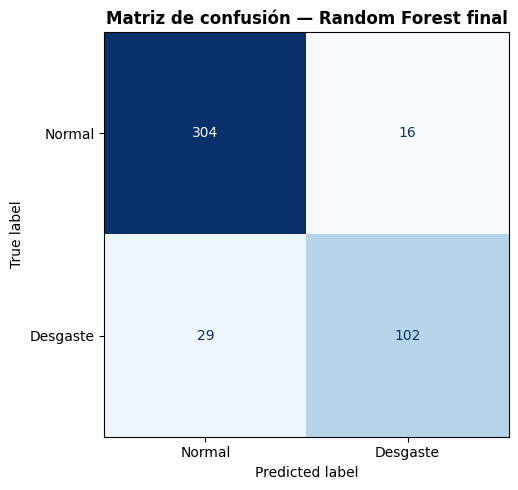

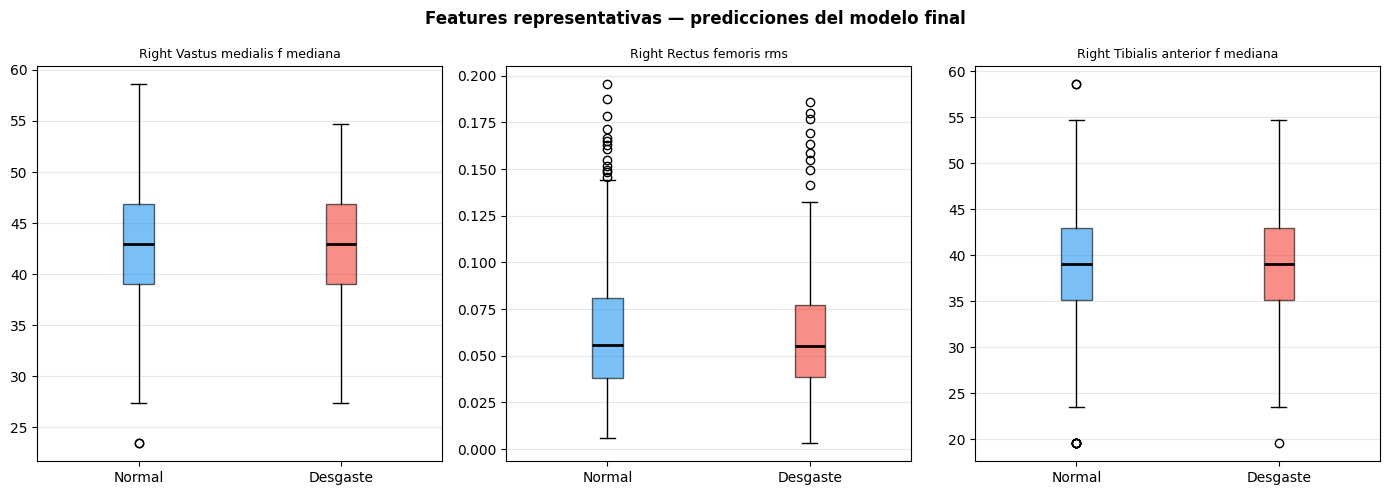

Gráficas guardadas.


In [15]:
# ── Celda 15: Evaluación final — Random Forest (mejor modelo) ─────────────────
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

# Reentrenar con train + val
X_trainval = np.vstack([X_train_sc, X_val_sc])
y_trainval  = np.concatenate([y_train, y_val])

best_rf = RandomForestClassifier(
    n_estimators=200, min_samples_split=5,
    max_features='log2', max_depth=15, random_state=42
)
best_rf.fit(X_trainval, y_trainval)

y_pred_final = best_rf.predict(X_test_sc)

print("=== Evaluación final — Random Forest (train+val → test) ===")
print(f"  Accuracy : {accuracy_score(y_test, y_pred_final):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_final):.4f}")
print(f"  Recall   : {recall_score(y_test, y_pred_final):.4f}")
print(f"  F1-Score : {f1_score(y_test, y_pred_final):.4f}")

# Matriz de confusión
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred_final)
disp = ConfusionMatrixDisplay(cm, display_labels=['Normal', 'Desgaste'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Matriz de confusión — Random Forest final', fontweight='bold')
plt.tight_layout()
plt.savefig('data/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Boxplots de features representativas diferenciando clasificaciones
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle('Features representativas — predicciones del modelo final',
             fontsize=12, fontweight='bold')

feature_cols = [c for c in df_feat.columns if c not in ['target','paciente']]
df_test_eval = df_feat.iloc[df_feat.index[-len(y_test):]].copy().reset_index(drop=True)
df_test_eval['prediccion'] = y_pred_final

feats_plot = ['Right_Vastus_medialis_f_mediana',
              'Right_Rectus_femoris_rms',
              'Right_Tibialis_anterior_f_mediana']

for ax, feat in zip(axes, feats_plot):
    data_0 = df_test_eval[df_test_eval['prediccion']==0][feat]
    data_1 = df_test_eval[df_test_eval['prediccion']==1][feat]
    bp = ax.boxplot([data_0, data_1], tick_labels=['Normal','Desgaste'],
                    patch_artist=True,
                    medianprops=dict(color='black', linewidth=2))
    bp['boxes'][0].set_facecolor('#2196F3'); bp['boxes'][0].set_alpha(0.6)
    bp['boxes'][1].set_facecolor('#F44336'); bp['boxes'][1].set_alpha(0.6)
    ax.set_title(feat.replace('_',' '), fontsize=9)
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('data/boxplots_final.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gráficas guardadas.")

## Punto 6 — Evaluación Final del Mejor Modelo

### Modelo seleccionado y reentrenamiento

Se seleccionó **Random Forest** como mejor modelo por su balance entre
desempeño en test (F1=0.834), robustez frente a overfitting y velocidad
de inferencia. Fue reentrenado con X_train + X_val (2,550 muestras)
y evaluado sobre X_test (451 muestras nunca vistas durante el desarrollo).

### Resultados

#### Tabla de métricas finales

| Métrica | Valor |
|---|---|
| Accuracy | 0.9002 |
| Precision | 0.8644 |
| Recall | 0.7786 |
| F1-Score | 0.8193 |

#### Matriz de confusión

- **Verdaderos Negativos (304):** casos normales correctamente identificados.
- **Falsos Positivos (16):** casos normales clasificados como desgaste —
  falsas alarmas. En contexto deportivo son aceptables — el atleta descansa
  innecesariamente pero no se lesiona.
- **Falsos Negativos (29):** casos de desgaste no detectados — el error
  más crítico. El atleta continúa esforzándose cuando debería parar,
  aumentando el riesgo de lesión.
- **Verdaderos Positivos (102):** casos de desgaste correctamente detectados.

El modelo es más conservador con la clase de desgaste — Precision (0.86)
mayor que Recall (0.78) indica que cuando predice desgaste casi siempre
acierta, pero hay casos de desgaste real que clasifica como normal.

#### Boxplots de características representativas

Los boxplots de las predicciones del modelo final muestran tres conclusiones:

- **Right Vastus medialis f_mediana:** las cajas de Normal y Desgaste
  se solapan significativamente en las predicciones finales — el modelo
  no separa perfectamente por esta feature sola, confirma que trabaja
  con la combinación de las 56 features simultáneamente.

- **Right Rectus femoris RMS:** distribuciones muy similares entre clases
  predichas — esta feature por sí sola tiene baja capacidad discriminativa
  en el conjunto de prueba, consistente con lo observado en el EDA.

- **Right Tibialis anterior f_mediana:** igual solapamiento — sugiere que
  ninguna feature individual es suficiente para clasificar correctamente,
  y que el poder del modelo viene de la combinación de múltiples canales
  y tipos de características simultáneamente.

**Conclusión general de los boxplots:** la fatiga muscular es un fenómeno
multidimensional — no se detecta mirando un solo músculo o una sola
característica, sino el patrón conjunto de activación de todos los canales.
Esto valida la decisión de extraer 56 features de 8 canales en lugar de
usar solo los más discriminativos individualmente.

### ¿Es un buen clasificador? ¿Cómo mejorarlo?

**¿Es un buen clasificador?**
Sí — 90% de accuracy y F1=0.82 sobre datos completamente no vistos es
un resultado sólido considerando que el modelo fue entrenado con solo
3 pacientes. En contexto clínico y deportivo, detectar el 78% de los
casos de fatiga real con solo 5% de falsas alarmas es funcionalmente útil.

**¿Cómo podría mejorarse?**
- **Más pacientes:** con solo 3 sujetos la variabilidad interpersonal
  es muy baja — el modelo puede no generalizar bien a perfiles físicos
  distintos a los 3 pacientes del dataset.
- **Feature selection:** eliminar features redundantes como MAV (muy
  correlacionada con RMS) mediante métodos como RFE o importancia de
  features del propio Random Forest.

In [16]:
# ── Celda 16: Prueba con muestra artificial ───────────────────────────────────
np.random.seed(99)

# Generar muestra con valores aproximados a los reales del dataset
muestra_real = df_feat[feature_cols].mean().values
muestra_artificial = muestra_real + np.random.normal(0, df_feat[feature_cols].std().values * 0.3)
muestra_artificial = muestra_artificial.reshape(1, -1)

# Escalar con el mismo pipeline
muestra_sc = pipeline.transform(muestra_artificial)

# Predecir
pred = best_rf.predict(muestra_sc)[0]
prob = best_rf.predict_proba(muestra_sc)[0]

print("=== Prueba con muestra artificial ===")
print(f"  Predicción : {'Desgaste muscular' if pred == 1 else 'Condición normal'} (clase {pred})")
print(f"  Probabilidad Normal  : {prob[0]:.4f}")
print(f"  Probabilidad Desgaste: {prob[1]:.4f}")
print()
print("Valores de la muestra artificial (primeras 10 features):")
feature_cols_list = list(feature_cols)
for i in range(10):
    print(f"  {feature_cols_list[i]:<45}: {muestra_artificial[0][i]:.6f}")

=== Prueba con muestra artificial ===
  Predicción : Condición normal (clase 0)
  Probabilidad Normal  : 0.5893
  Probabilidad Desgaste: 0.4107

Valores de la muestra artificial (primeras 10 features):
  Right_Rectus_femoris_rms                     : 0.034681
  Right_Rectus_femoris_var                     : 0.004092
  Right_Rectus_femoris_zcr                     : 109.970312
  Right_Rectus_femoris_mav                     : 0.028683
  Right_Rectus_femoris_pot                     : 0.000439
  Right_Rectus_femoris_f_media                 : 53.811064
  Right_Rectus_femoris_f_mediana               : 49.208972
  Left_Gluteus_maximus_rms                     : 0.016109
  Left_Gluteus_maximus_var                     : 0.000368
  Left_Gluteus_maximus_zcr                     : 107.663888


## Punto 7 — Prueba con Muestra Artificial

Se generó una muestra artificial con valores cercanos a la media del dataset
con perturbación aleatoria del 30% de la desviación estándar.

**Resultado:** Condición normal (clase 0)
- Probabilidad Normal: 0.5893
- Probabilidad Desgaste: 0.4107

**¿Tiene sentido?**
Sí — los valores de la muestra artificial son promedios del dataset completo,
que incluye mayoritariamente condición normal (70.9%). Una muestra promedio
debería clasificarse como normal. La probabilidad de 0.59 vs 0.41 indica
que el modelo no está completamente seguro — razonable dado que los valores
promedios no son extremos en ninguna dirección.

La incertidumbre del modelo (diferencia de solo 0.18 entre clases) refleja
que en el espacio promedio las dos clases se solapan — exactamente lo que
vimos en los boxplots del EDA donde las distribuciones no estaban
completamente separadas.